# Gate Synthesis for Qubit-Qudit Mediated Two-Qubit Gates

Product-of-exponentials gate synthesis using gradient-based optimization (pure JAX + optax).

At each of $M$ timesteps the system evolves under a piecewise-constant Hamiltonian
$$H_k = \sum_j \Omega_{k,j}\, G_j,$$
producing the total propagator
$$U = \prod_{k=1}^{M} e^{-i\, H_k\, T/M}.$$
The real-valued amplitudes $\Omega_{k,j}$ are optimized via Adam (optax) with
gradients from `jax.value_and_grad` flowing through `jax.scipy.linalg.expm`.

---

| Tier | Problem | Generators | Target | Constraint |
|------|---------|------------|--------|------------|
| **0** | Two-qubit SWAP benchmark | $\sigma^a \otimes \sigma^b$ (15 ops, 4×4) | SWAP | $\|H_k\|_{\mathrm{op}} \le 1$ sweep to verify $T_{\min} = 3\pi/4$ |
| **1** | Qudit-mediated SWAP | $\sigma_i^a \otimes S^b$ (27 ops) | $U_{\mathrm{swap}} \otimes I_d$ | Unbounded $\Omega$, $T=1$ |
| **2** | Speed limit analysis | same as Tier 1 | same | $\|H_k\|_{\mathrm{op}} \le 1$, sweep $T$ |

## Imports and configuration

We use 64-bit arithmetic throughout for the fidelity calculations that need
precision near $F = 1$.

In [1]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
import optax
import matplotlib.pyplot as plt
import numpy as np
from concurrent.futures import ThreadPoolExecutor

jax.config.update("jax_enable_x64", True)

## Operator definitions

**Pauli matrices** $\{I, \sigma_x, \sigma_y, \sigma_z\}$ for qubits and
**spin-$s$ operators** $\{I, S_x, S_y, S_z\}$ for the qudit (dimension $d = 2s+1$).

The generators for Tier 0 are the 15 traceless two-qubit Pauli products
$\sigma^a \otimes \sigma^b$ (excluding $I \otimes I$, which only contributes
global phase).

In [2]:
# ── Pauli matrices (qubit) ──
I2 = jnp.eye(2, dtype=jnp.complex128)
sx = jnp.array([[0, 1], [1, 0]], dtype=jnp.complex128)
sy = jnp.array([[0, -1j], [1j, 0]], dtype=jnp.complex128)
sz = jnp.array([[1, 0], [0, -1]], dtype=jnp.complex128)
paulis = {"I": I2, "x": sx, "y": sy, "z": sz}


def generate_spin_operators(s):
    """Build {I, Sx, Sy, Sz} for spin quantum number s (dimension 2s+1).

    Uses the standard raising/lowering operator construction:
      S+ |s,m> = sqrt(s(s+1) - m(m+1)) |s, m+1>
      Sx = (S+ + S-)/2,  Sy = (S+ - S-)/(2i)
    """
    d = int(2 * s + 1)
    m_vals = jnp.array([s - k for k in range(d)])

    Sz = jnp.diag(m_vals.astype(jnp.complex128))

    # S+ matrix elements: <m+1|S+|m>
    sp_diag = jnp.array([
        jnp.sqrt(s * (s + 1) - m_vals[k + 1] * (m_vals[k + 1] + 1))
        for k in range(d - 1)
    ]).astype(jnp.complex128)
    Sp = jnp.diag(sp_diag, k=1)
    Sm = Sp.conj().T

    Sx = (Sp + Sm) / 2
    Sy = (Sp - Sm) / 2j
    return {"I": jnp.eye(d, dtype=jnp.complex128), "x": Sx, "y": Sy, "z": Sz}


def build_pauli_basis():
    """15 two-qubit Pauli tensor products {sigma^a (x) sigma^b}, excluding I(x)I."""
    generators, labels = [], []
    for a, sa in paulis.items():
        for b, sb in paulis.items():
            if a == "I" and b == "I":
                continue
            generators.append(jnp.kron(sa, sb))
            labels.append(f"\u03c3{a}\u2297\u03c3{b}")
    return jnp.stack(generators), labels


def build_swap_gate():
    """4x4 SWAP gate: |ij> -> |ji>."""
    swap = jnp.zeros((4, 4), dtype=jnp.complex128)
    for i in range(2):
        for j in range(2):
            swap = swap.at[j * 2 + i, i * 2 + j].set(1.0)
    return swap


# Build and validate
generators_t0, labels_t0 = build_pauli_basis()
U_swap = build_swap_gate()

print(f"Tier 0: {len(labels_t0)} generators of shape {generators_t0.shape[1:]}")
print(f"Labels: {labels_t0}")
print(f"\nSWAP gate:\n{np.array(U_swap.real, dtype=int)}")
assert jnp.allclose(U_swap @ U_swap, jnp.eye(4)), "SWAP^2 != I"

Tier 0: 15 generators of shape (4, 4)
Labels: ['σI⊗σx', 'σI⊗σy', 'σI⊗σz', 'σx⊗σI', 'σx⊗σx', 'σx⊗σy', 'σx⊗σz', 'σy⊗σI', 'σy⊗σx', 'σy⊗σy', 'σy⊗σz', 'σz⊗σI', 'σz⊗σx', 'σz⊗σy', 'σz⊗σz']

SWAP gate:
[[1 0 0 0]
 [0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]]


## Forward pass, fidelity, and optimizer

**Propagator**: At each of $M$ steps, form $H_k = \sum_j \Omega_{k,j} G_j$
and compute $U_k = e^{-i H_k \Delta t}$ via `jax.scipy.linalg.expm`. The
full propagator is the ordered product $U = U_M \cdots U_1$, evaluated with
`jax.lax.scan`.

**Operator-norm bound**: For the bounded case, each $H_k$ is rescaled so that
$\|H_k\|_{\mathrm{op}} \le 1$. Since the generators are Hermitian, the
operator norm is $\max|\lambda_i|$ from `eigvalsh`, which is differentiable.

**Fidelity**: The phase-invariant average gate fidelity
$$F = \frac{|\mathrm{Tr}(U_{\mathrm{target}}^\dagger U)|^2 + d}{d(d+1)}$$
where $d$ is the Hilbert space dimension.

**Multi-restart optimization**: Because the loss landscape has local minima,
we run many random initializations and keep the best result.

In [4]:
def normalize_omegas(omegas, generators):
    """Rescale amplitudes at each timestep so ||H_k||_op <= 1.

    Args:
        omegas: (M, n_gen) raw amplitudes.
        generators: (n_gen, d, d) Hermitian basis operators.
    Returns:
        (M, n_gen) rescaled amplitudes.
    """
    def norm_step(omega_k):
        H_k = jnp.einsum('j,jab->ab', omega_k, generators)
        # Operator norm of Hermitian matrix = max |eigenvalue|
        op_norm = jnp.max(jnp.abs(jnp.linalg.eigvalsh(H_k)))
        return omega_k / jnp.maximum(op_norm, 1.0)
    return jax.vmap(norm_step)(omegas)  # vmap over M timesteps


def cosine_parametrize(thetas):
    """Map unconstrained thetas to bounded amplitudes via cos(theta).

    Each Omega_j = cos(theta_j) is independently bounded in [-1, 1].

    Args:
        thetas: (M, n_gen) unconstrained parameters.
    Returns:
        (M, n_gen) amplitudes in [-1, 1].
    """
    return jnp.cos(thetas)


def cosine_parametrize_normalized(thetas, generators):
    """Map thetas to amplitudes via cos(theta_j) / ||G_j||_op.

    Each term Omega_j * G_j has operator norm <= 1, since
    |Omega_j| <= 1/||G_j||_op.

    Args:
        thetas: (M, n_gen) unconstrained parameters.
        generators: (n_gen, d, d) Hermitian basis operators.
    Returns:
        (M, n_gen) amplitudes bounded by 1/||G_j||_op.
    """
    # Precompute operator norms of each generator (shape: (n_gen,))
    @jax.jit
    def gen_op_norm(G):
        return jnp.max(jnp.abs(jnp.linalg.eigvalsh(G)))
    op_norms = jax.vmap(gen_op_norm)(generators)  # (n_gen,)
    return jnp.cos(thetas) / op_norms[None, :]    # broadcast over M


def product_of_exponentials(omegas, generators, T, bounded=False, constraint="none"):
    """Compute U = prod_k exp(-i H_k dt) via scan over M steps.

    Args:
        omegas: (M, n_gen) real amplitudes per timestep.
        generators: (n_gen, d, d) Hermitian basis operators.
        T: total evolution time.
        bounded: if True, enforce ||H_k||_op <= 1 at each step (legacy).
        constraint: "none", "op_norm", "cosine", or "cosine_normalized".
                    If bounded=True and constraint="none", uses "op_norm"
                    for backward compatibility.
    Returns:
        (d, d) unitary propagator U(T).
    """
    # Backward compatibility: bounded=True maps to op_norm constraint
    if bounded and constraint == "none":
        constraint = "op_norm"

    if constraint == "op_norm":
        omegas = normalize_omegas(omegas, generators)
    elif constraint == "cosine":
        omegas = cosine_parametrize(omegas)
    elif constraint == "cosine_normalized":
        omegas = cosine_parametrize_normalized(omegas, generators)

    M = omegas.shape[0]
    d = generators.shape[1]
    dt = T / M

    def scan_fn(U_carry, omega_k):
        # Build Hamiltonian for this timestep: H_k = sum_j omega_j * G_j
        H_k = jnp.einsum('j,jab->ab', omega_k, generators)
        # Unitary for this step
        U_k = expm(-1j * H_k * dt)
        # Accumulate: U_{k} @ U_{k-1} @ ... @ U_1
        return U_k @ U_carry, None

    U_init = jnp.eye(d, dtype=jnp.complex128)
    U_final, _ = jax.lax.scan(scan_fn, U_init, omegas)
    return U_final


def average_gate_fidelity(U, U_target):
    """Phase-invariant average gate fidelity."""
    d = U.shape[0]
    overlap = jnp.trace(U_target.conj().T @ U)
    return (jnp.abs(overlap) ** 2 + d) / (d * (d + 1))


def optimize_gate(
    generators, U_target, M, T,
    n_restarts=50, epochs=3000, lr=0.01,
    bounded=False, constraint="none",
    seed=0, verbose=True, init_scale=1.0,
):
    """Multi-restart Adam optimization for gate synthesis.

    Args:
        generators: (n_gen, d, d) Hermitian generators.
        U_target: (d, d) target unitary.
        M: number of piecewise-constant timesteps.
        T: total evolution time.
        n_restarts: number of random restarts.
        epochs: max gradient steps per restart.
        lr: Adam learning rate.
        bounded: enforce ||H_k||_op <= 1 (legacy, use constraint instead).
        constraint: "none", "op_norm", "cosine", or "cosine_normalized".
        seed: base PRNG seed.
        verbose: print progress.
        init_scale: std dev of random initial amplitudes.
    Returns:
        (best_omegas, best_fidelity, best_loss_history)
    """
    n_gen = generators.shape[0]
    optimizer = optax.adam(lr)

    # Close over all fixed data so the JIT-compiled step is tight
    def loss_fn(omegas):
        U = product_of_exponentials(omegas, generators, T,
                                    bounded=bounded, constraint=constraint)
        return 1.0 - average_gate_fidelity(U, U_target)

    @jax.jit
    def step(omegas, opt_state):
        loss, grads = jax.value_and_grad(loss_fn)(omegas)
        updates, new_opt_state = optimizer.update(grads, opt_state, omegas)
        omegas = optax.apply_updates(omegas, updates)
        return omegas, new_opt_state, loss

    best_fidelity = -1.0
    best_omegas = None
    best_history = None

    for restart in range(n_restarts):
        key = jax.random.PRNGKey(seed + restart)
        omegas = init_scale * jax.random.normal(key, (M, n_gen))
        opt_state = optimizer.init(omegas)
        history = []

        for epoch in range(epochs):
            omegas, opt_state, loss = step(omegas, opt_state)
            history.append(float(loss))
            if loss < 1e-12:
                break

        fid = 1.0 - history[-1]
        if fid > best_fidelity:
            best_fidelity = fid
            best_omegas = omegas
            best_history = history

        if verbose and (restart < 5 or (restart + 1) % 10 == 0):
            print(f"  restart {restart+1:3d}/{n_restarts}: "
                  f"F = {fid:.10f}  (epochs: {len(history)})")

        # Early exit if essentially perfect
        if best_fidelity > 1.0 - 1e-12:
            if verbose:
                print(f"  ** converged at restart {restart+1} **")
            break

    if verbose:
        print(f"  Best fidelity: {best_fidelity:.12f}")
    return best_omegas, best_fidelity, best_history


def optimize_gate_fast(
    generators, U_target, M, T,
    n_restarts=50, epochs=3000, lr=0.01,
    bounded=False, constraint="none",
    seed=0, verbose=True, init_scale=1.0,
):
    """Vectorized multi-restart optimization using vmap + lax.scan.

    All restarts run in parallel via jax.vmap, and the epoch loop is
    compiled into XLA via jax.lax.scan — no Python-level iteration.

    Note: early exit is not supported; all restarts run for the full
    number of epochs.  Use the original optimize_gate when early
    convergence is expected (e.g. small Hilbert spaces).

    Returns:
        (best_omegas, best_fidelity, best_history)
    """
    n_gen = generators.shape[0]
    optimizer = optax.adam(lr)

    def loss_fn(omegas):
        U = product_of_exponentials(omegas, generators, T,
                                    bounded=bounded, constraint=constraint)
        return 1.0 - average_gate_fidelity(U, U_target)

    def step_single(omegas, opt_state):
        loss, grads = jax.value_and_grad(loss_fn)(omegas)
        updates, new_opt_state = optimizer.update(grads, opt_state, omegas)
        new_omegas = optax.apply_updates(omegas, updates)
        return new_omegas, new_opt_state, loss

    def scan_body(carry, _):
        all_omegas, all_opt_states = carry
        new_omegas, new_opt_states, losses = jax.vmap(step_single)(
            all_omegas, all_opt_states
        )
        return (new_omegas, new_opt_states), losses

    keys = jax.random.split(jax.random.PRNGKey(seed), n_restarts)
    all_omegas = jax.vmap(
        lambda k: init_scale * jax.random.normal(k, (M, n_gen))
    )(keys)
    all_opt_states = jax.vmap(optimizer.init)(all_omegas)

    if verbose:
        print(f"  Compiling {n_restarts} restarts × {epochs} epochs …")

    (final_omegas, _), loss_history = jax.jit(
        lambda o, s: jax.lax.scan(scan_body, (o, s), None, length=epochs)
    )(all_omegas, all_opt_states)

    # loss_history shape: (epochs, n_restarts)
    best_per_restart = jnp.min(loss_history, axis=0)
    best_idx = jnp.argmin(best_per_restart)
    best_fidelity = float(1.0 - best_per_restart[best_idx])
    best_omegas = final_omegas[best_idx]
    best_history = np.asarray(loss_history[:, best_idx])

    if verbose:
        for r in range(n_restarts):
            fid = float(1.0 - best_per_restart[r])
            if r < 5 or (r + 1) % 10 == 0:
                print(f"  restart {r+1:3d}/{n_restarts}: F = {fid:.10f}")
        print(f"  Best fidelity: {best_fidelity:.12f}")

    return best_omegas, best_fidelity, best_history


def sweep_fidelity(generators, U_target, T_values, M, label,
                   n_restarts=30, epochs=4000, lr=0.005,
                   constraint="op_norm", init_scale=0.3,
                   use_fast=True, verbose=True):
    """Sweep over T values sequentially.

    Args:
        constraint: "op_norm", "cosine", or "cosine_normalized".
        use_fast: if True, use optimize_gate_fast (vmapped); else optimize_gate.
    Returns:
        np.array of fidelities.
    """
    opt_fn = optimize_gate_fast if use_fast else optimize_gate
    fidelities = []
    for i, T_val in enumerate(T_values):
        _, fid, _ = opt_fn(
            generators, U_target, M=M, T=float(T_val),
            n_restarts=n_restarts, epochs=epochs, lr=lr,
            constraint=constraint, verbose=verbose, init_scale=init_scale,
        )
        print(f"  [{label}] T = {T_val:.3f}  |  F = {fid:.8f}  "
              f"({i + 1}/{len(T_values)})")
        fidelities.append(fid)
    return np.array(fidelities)


def sweep_fidelity_parallel(generators, U_target, T_values, M, label,
                            n_restarts=30, epochs=4000, max_workers=2,
                            constraint="op_norm"):
    """Sweep over T values using ThreadPoolExecutor for parallelism.

    Each thread dispatches an independent optimize_gate_fast call;
    JAX handles internal parallelism within each call.
    """
    # Determine bounded flag for backward compatibility
    _bounded = (constraint == "op_norm")
    _constraint = constraint

    def run_one(args):
        i, T_val = args
        _, fid, _ = optimize_gate_fast(
            generators, U_target, M=M, T=float(T_val),
            n_restarts=n_restarts, epochs=epochs, lr=0.005,
            bounded=_bounded, constraint=_constraint,
            verbose=True, init_scale=0.3,
        )
        print(f"  [{label}] T = {T_val:.3f}  |  F = {fid:.8f}  "
              f"({i + 1}/{len(T_values)})")
        return i, fid

    fidelities = [None] * len(T_values)
    with ThreadPoolExecutor(max_workers=min(max_workers, len(T_values))) as pool:
        for i, fid in pool.map(run_one, enumerate(T_values)):
            fidelities[i] = fid
    return np.array(fidelities)

---
## Tier 0 — Benchmark: Two-Qubit SWAP (unbounded $\Omega$)

Hilbert space $\mathbb{C}^2 \otimes \mathbb{C}^2$ (dim 4). With unbounded
amplitudes and $T=1$ this should converge to $F = 1$ easily, validating the
optimization pipeline.

In [ ]:
M_t0 = 20   # timesteps
T_t0 = 1.0  # total evolution time (arbitrary when Omega is unbounded)

print(f"Tier 0: {len(labels_t0)} generators, M = {M_t0}, T = {T_t0}")
print(f"Total parameters: {len(labels_t0)} x {M_t0} = {M_t0 * len(labels_t0)}")

omegas_t0, fid_t0, hist_t0 = optimize_gate(
    generators_t0, U_swap, M=M_t0, T=T_t0,
    n_restarts=50, epochs=3000, lr=0.01,
    bounded=False, verbose=True,
)

# ── Convergence plot ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hist_t0)
ax.set(xlabel="Epoch", ylabel="Infidelity (1 - F)")
ax.set_title(f"Tier 0: Two-Qubit SWAP (unbounded) — F = {fid_t0:.10f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Tier 0 — Speed limit sweep ($\|H_k\|_{\mathrm{op}} \le 1$)

Now we constrain the operator norm of each $H_k$ to at most 1 and sweep the
total time $T$. The known analytical speed limit for the two-qubit SWAP gate
is
$$T_{\min} = \frac{3\pi}{4} \approx 2.356.$$
Below this time, unit fidelity is impossible; above it, the optimizer should
recover $F \to 1$.

In [9]:
T_min_exact = 3 * np.pi / 4  # analytical SWAP speed limit
M_sweep = 40                  # enough steps to approximate continuous control

# Dense sampling near the expected transition at T_min
T_values_t0 = jnp.concatenate([
    np.linspace(0.8, 3.5, 25),
])

print(f"T_min (exact) = {T_min_exact:.4f}")
print(f"Sweeping {len(T_values_t0)} values of T with M = {M_sweep} ...")

fidelities_t0_bounded = []
for i, T_val in enumerate(T_values_t0):
    _, fid, _ = optimize_gate(
        generators_t0, U_swap, M=M_sweep, T=float(T_val),
        n_restarts=30, epochs=4000, lr=0.005,
        constraint="cosine", verbose=False, init_scale=0.5,
    )
    fidelities_t0_bounded.append(fid)
    tag = "< T_min" if T_val < T_min_exact else ">= T_min"
    print(f"  T = {T_val:.3f}  |  F = {fid:.8f}  ({tag})")

fidelities_t0_bounded = jnp.array(fidelities_t0_bounded)

T_min (exact) = 2.3562
Sweeping 25 values of T with M = 40 ...
  T = 0.800  |  F = 0.99979240  (< T_min)


KeyboardInterrupt: 

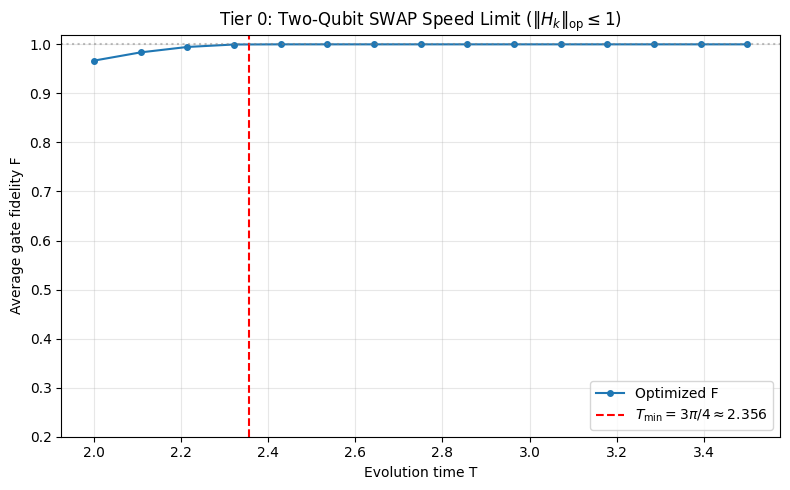

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_values_t0, fidelities_t0_bounded, 'o-', ms=4, label="Optimized F")
ax.axvline(T_min_exact, color='r', ls='--', lw=1.5,
           label=f"$T_{{\\min}} = 3\\pi/4 \\approx {T_min_exact:.3f}$")
ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
ax.set(xlabel="Evolution time T", ylabel="Average gate fidelity F")
ax.set_title(r"Tier 0: Two-Qubit SWAP Speed Limit ($\|H_k\|_{\mathrm{op}} \leq 1$)")
ax.legend()
ax.set_ylim(0.2, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Tier 1 — Qudit-Mediated SWAP

### Operator basis

Hilbert space: qubit$_1 \otimes$ qubit$_2 \otimes$ qudit, total dimension $4d$.

Each generator couples **one qubit** to the qudit:
- Qubit 1 $\leftrightarrow$ qudit: $\sigma_1^a \otimes I_2 \otimes S^b$
- Qubit 2 $\leftrightarrow$ qudit: $I_2 \otimes \sigma_2^a \otimes S^b$

where $a \in \{I, x, y, z\}$ and $S^b$ is the appropriate spin operator
(Pauli for $d=2$, spin-3/2 for $d=4$). After removing the trivial
$I \otimes I \otimes I$ and deduplicating the $I \otimes I \otimes S^b$
terms that appear from both qubits, we get **27 unique generators**.

The target unitary is $U_{\mathrm{swap}} \otimes I_d$ — the SWAP acts on the
two-qubit subspace while the qudit is returned to its initial state.

In [12]:
def build_qudit_mediated_basis(d_qudit):
    """Build the Hermitian generator set for two qubits coupled to a qudit.

    Hilbert space ordering: qubit1 (x) qubit2 (x) qudit.

    Returns:
        generators: (n_gen, 4*d_qudit, 4*d_qudit) stacked array
        labels: list of human-readable strings
    """
    # Pick the right spin-s representation for the qudit
    if d_qudit == 2:
        spin_ops = paulis                          # spin-1/2 = Pauli
    else:
        s = (d_qudit - 1) / 2
        spin_ops = generate_spin_operators(s)      # spin-3/2, etc.

    generators, labels = [], []
    seen = set()

    for qubit_idx in [1, 2]:
        for a, sigma_a in paulis.items():
            for b, S_b in spin_ops.items():
                if a == "I" and b == "I":
                    continue  # global identity is trivial

                # I (x) I (x) S_b is the same regardless of which qubit
                if a == "I":
                    label = f"I\u2297I\u2297S{b}"
                else:
                    label = f"q{qubit_idx}:\u03c3{a}\u2297S{b}"

                if label in seen:
                    continue
                seen.add(label)

                # Tensor product: qubit1 (x) qubit2 (x) qudit
                if qubit_idx == 1:
                    op = jnp.kron(jnp.kron(sigma_a, I2), S_b)
                else:
                    op = jnp.kron(jnp.kron(I2, sigma_a), S_b)

                generators.append(op)
                labels.append(label)

    gen_array = jnp.stack(generators)

    # Sanity check: all generators must be Hermitian
    for k in range(gen_array.shape[0]):
        assert jnp.allclose(gen_array[k], gen_array[k].conj().T), \
            f"Generator {labels[k]} is not Hermitian"

    return gen_array, labels


def build_swap_qudit_target(d_qudit):
    """U_swap (x) I_d: SWAP on qubits, identity on qudit."""
    return jnp.kron(U_swap, jnp.eye(d_qudit, dtype=jnp.complex128))


# ── Build for d = 2 and d = 4 ──
generators_d2, labels_d2 = build_qudit_mediated_basis(2)
generators_d4, labels_d4 = build_qudit_mediated_basis(4)
U_target_d2 = build_swap_qudit_target(2)
U_target_d4 = build_swap_qudit_target(4)

print(f"d = 2: {len(labels_d2)} generators, Hilbert space dim = {generators_d2.shape[1]}")
print(f"d = 4: {len(labels_d4)} generators, Hilbert space dim = {generators_d4.shape[1]}")
print(f"\nU_target shapes: d=2 -> {U_target_d2.shape},  d=4 -> {U_target_d4.shape}")

d = 2: 27 generators, Hilbert space dim = 8
d = 4: 27 generators, Hilbert space dim = 16

U_target shapes: d=2 -> (8, 8),  d=4 -> (16, 16)


### Tier 1 — Optimization (unbounded $\Omega$, $T = 1$)

With unconstrained amplitudes and $T = 1$, this tests whether the
qudit-mediated generator set is *controllable* — i.e., whether the Lie algebra
spans $\mathfrak{su}(4d)$. If $F \to 1$, the SWAP gate can indeed be
synthesised through qudit-mediated interactions alone.

In [30]:
M_t1 = 30   # timesteps (more needed for larger Hilbert space)
T_t1 = 1.0

print("=" * 60)
print(f"Tier 1 (d=2): {len(labels_d2)} generators, M = {M_t1}")
print(f"Hilbert space dim = {generators_d2.shape[1]}, "
      f"params = {len(labels_d2) * M_t1}")
print("=" * 60)

omegas_d2, fid_d2, hist_d2 = optimize_gate(
    generators_d2, U_target_d2, M=M_t1, T=T_t1,
    n_restarts=50, epochs=5000, lr=0.005,
    bounded=False, verbose=True, init_scale=0.5,
)
print(f"\n  d=2 result: F = {fid_d2:.12f}")

Tier 1 (d=2): 27 generators, M = 30
Hilbert space dim = 8, params = 810
  restart   1/50: F = 1.0000000000  (epochs: 3341)
  ** converged at restart 1 **
  Best fidelity: 0.999999999999

  d=2 result: F = 0.999999999999


In [31]:
print("=" * 60)
print(f"Tier 1 (d=4): {len(labels_d4)} generators, M = {M_t1}")
print(f"Hilbert space dim = {generators_d4.shape[1]}, "
      f"params = {len(labels_d4) * M_t1}")
print("=" * 60)

omegas_d4, fid_d4, hist_d4 = optimize_gate_fast(
    generators_d4, U_target_d4, M=M_t1, T=T_t1,
    n_restarts=50, epochs=5000, lr=0.005,
    bounded=False, verbose=True, init_scale=0.5,
)
print(f"\n  d=4 result: F = {fid_d4:.12f}")

Tier 1 (d=4): 27 generators, M = 30
Hilbert space dim = 16, params = 810
  Compiling 50 restarts × 5000 epochs …
  restart   1/50: F = 0.9999975114
  restart   2/50: F = 0.9999981618
  restart   3/50: F = 0.9999995475
  restart   4/50: F = 0.9999933138
  restart   5/50: F = 0.9999999143
  restart  10/50: F = 0.9999793167
  restart  20/50: F = 0.9999935042
  restart  30/50: F = 0.9999944310
  restart  40/50: F = 0.9999983452
  restart  50/50: F = 0.9999743803
  Best fidelity: 0.999999999878

  d=4 result: F = 0.999999999878


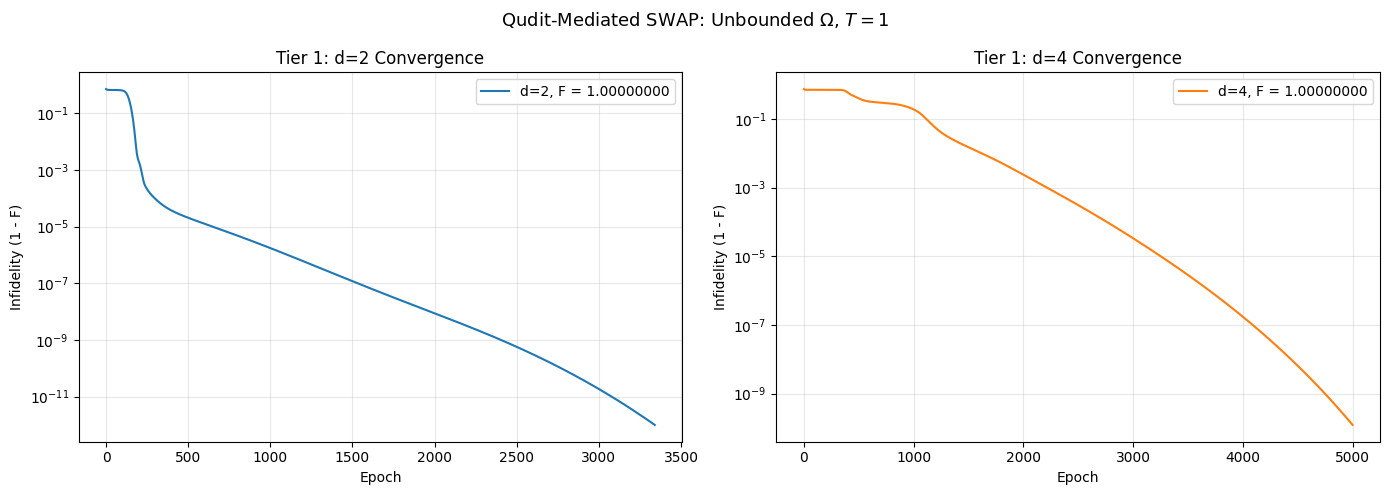

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, fid, d_label, color in [
    (axes[0], hist_d2, fid_d2, "d=2", "C0"),
    (axes[1], hist_d4, fid_d4, "d=4", "C1"),
]:
    ax.semilogy(hist, color=color, label=f"{d_label}, F = {fid:.8f}")
    ax.set(xlabel="Epoch", ylabel="Infidelity (1 - F)")
    ax.set_title(f"Tier 1: {d_label} Convergence")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(r"Qudit-Mediated SWAP: Unbounded $\Omega$, $T = 1$", fontsize=13)
plt.tight_layout()
plt.show()

---
## Tier 2 — Speed Limit Analysis ($\|H_k\|_{\mathrm{op}} \le 1$)

With the operator norm of each $H_k$ bounded by 1, there is a minimum
evolution time $T_{\min}$ below which the target gate cannot be reached.
We sweep $T$ and plot the optimized fidelity for both $d = 2$ and $d = 4$
to determine:

1. The numerical speed limit for the qudit-mediated SWAP.
2. Whether increasing the qudit dimension $d$ lowers $T_{\min}$ (i.e.,
   provides a speed-up).

This is analogous to Fig. 3 in [Howard *et al.*, PRR **5**, 043194 (2023)](https://doi.org/10.1103/PhysRevResearch.5.043194).

In [35]:
M_t2 = 40  # timesteps for the bounded sweep

# Dense sampling near the expected transition region (no duplicate at T=4)
T_values_t2 = np.concatenate([
    np.linspace(2.0, 12.0, 12, endpoint=False),
])

print("Sweeping d = 2 ...")
fid_sweep_d2 = sweep_fidelity_parallel(
    generators_d2, U_target_d2, T_values_t2, M_t2, "d=2",
)

print("\nSweeping d = 4 ...")
fid_sweep_d4 = sweep_fidelity_parallel(
    generators_d4, U_target_d4, T_values_t2, M_t2, "d=4",
)

Sweeping d = 2 ...
  Compiling 30 restarts × 4000 epochs …
  Compiling 30 restarts × 4000 epochs …
  restart   1/30: F = 0.5686847636
  restart   1/30: F = 0.4131357803
  restart   2/30: F = 0.5688002865
  restart   3/30: F = 0.5687536291
  restart   4/30: F = 0.5688274428
  restart   2/30: F = 0.4131980915
  restart   5/30: F = 0.5687941830
  restart   3/30: F = 0.4131589108
  restart   4/30: F = 0.4131587600
  restart   5/30: F = 0.4131643759
  restart  10/30: F = 0.5687279542
  restart  10/30: F = 0.4131762912
  restart  20/30: F = 0.5686449635
  restart  20/30: F = 0.4131253973
  restart  30/30: F = 0.5687122455
  Best fidelity: 0.568849953736
  [d=2] T = 2.833  |  F = 0.56884995  (2/12)
  restart  30/30: F = 0.4131624215
  Best fidelity: 0.413225745167
  [d=2] T = 2.000  |  F = 0.41322575  (1/12)
  Compiling 30 restarts × 4000 epochs …
  Compiling 30 restarts × 4000 epochs …
  restart   1/30: F = 0.7989543525
  restart   2/30: F = 0.7991762189
  restart   3/30: F = 0.7990609425
  

### Speed limit comparison plot

The red dashed line marks the two-qubit-only analytical speed limit
$T_{\min} = 3\pi/4$. If the qudit-mediated curves cross $F \approx 1$ at a
**smaller** $T$, the qudit mediator provides a genuine speed-up.

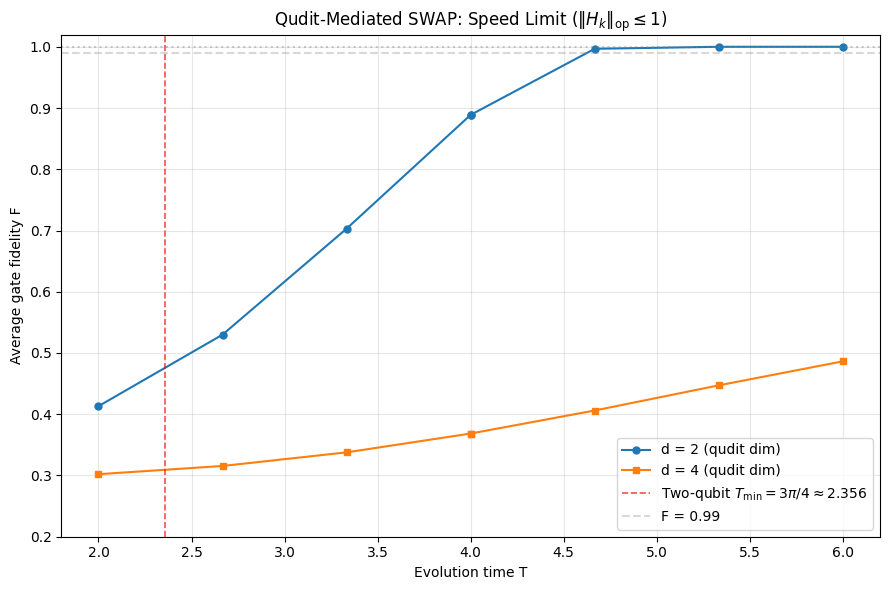


Two-qubit analytical T_min = 2.3562
  d=2: F >= 0.99 first at T = 4.667
  d=4: F never reached 0.99 in sweep range


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(T_values_t2, fid_sweep_d2, 'o-', ms=5,
        label="d = 2 (qudit dim)", color="C0")
ax.plot(T_values_t2, fid_sweep_d4, 's-', ms=5,
        label="d = 4 (qudit dim)", color="C1")
ax.axvline(T_min_exact, color='r', ls='--', lw=1.2, alpha=0.7,
           label=f"Two-qubit $T_{{\\min}} = 3\\pi/4 \\approx {T_min_exact:.3f}$")
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axhline(0.99, color='gray', ls='--', alpha=0.3, label="F = 0.99")

ax.set(xlabel="Evolution time T", ylabel="Average gate fidelity F")
ax.set_title(r"Qudit-Mediated SWAP: Speed Limit ($\|H_k\|_{\mathrm{op}} \leq 1$)")
ax.legend(fontsize=10)
ax.set_ylim(0.2, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("speed_limit_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print summary ──
print(f"\nTwo-qubit analytical T_min = {T_min_exact:.4f}")
for d_label, fids in [("d=2", fid_sweep_d2), ("d=4", fid_sweep_d4)]:
    above_99 = T_values_t2[fids >= 0.99]
    if len(above_99) > 0:
        print(f"  {d_label}: F >= 0.99 first at T = {above_99[0]:.3f}")
    else:
        print(f"  {d_label}: F never reached 0.99 in sweep range")

---
## Tier 3 — Cosine Parametrization: $\Omega_j = \cos(\theta_j)$

Instead of constraining the operator norm of the total Hamiltonian $\|H_k\|_{\mathrm{op}} \le 1$,
we bound each coefficient independently: $\Omega_{k,j} = \cos(\theta_{k,j}) \in [-1, 1]$.

This is **less restrictive** than the operator-norm bound because the total Hamiltonian
norm can be up to $\sum_j \|G_j\|_{\mathrm{op}}$ (e.g., 15 for Tier 0 Paulis).
It is also **physically fairer** when comparing different ancilla dimensions, since
the operator norm constraint penalizes systems with more or larger generators.

### Tier 0 benchmark: Two-qubit SWAP with $\cos(\theta)$

All 15 Pauli generators have $\|G_j\|_{\mathrm{op}} = 1$, so the max Hamiltonian
norm is 15. We expect the speed limit to be much shorter than $3\pi/4$.

Tier 0 cos(theta) sweep: 15 Pauli generators, each |Omega_j| <= 1
Max ||H_k||_op = 15 (if all coefficients saturate)
Sweeping T in [0.05, 1.00], M = 40

  [T0-cos] T = 0.050  |  F = 0.40714488  (1/20)
  [T0-cos] T = 0.100  |  F = 0.43250415  (2/20)
  [T0-cos] T = 0.150  |  F = 0.47981458  (3/20)
  [T0-cos] T = 0.200  |  F = 0.54900881  (4/20)
  [T0-cos] T = 0.250  |  F = 0.63574854  (5/20)
  [T0-cos] T = 0.300  |  F = 0.73158126  (6/20)
  [T0-cos] T = 0.350  |  F = 0.82560962  (7/20)
  [T0-cos] T = 0.400  |  F = 0.90746844  (8/20)
  [T0-cos] T = 0.450  |  F = 0.96629329  (9/20)
  [T0-cos] T = 0.500  |  F = 0.99652746  (10/20)
  [T0-cos] T = 0.550  |  F = 1.00000000  (11/20)
  [T0-cos] T = 0.600  |  F = 1.00000000  (12/20)
  [T0-cos] T = 0.650  |  F = 1.00000000  (13/20)
  [T0-cos] T = 0.700  |  F = 1.00000000  (14/20)
  [T0-cos] T = 0.750  |  F = 1.00000000  (15/20)
  [T0-cos] T = 0.800  |  F = 1.00000000  (16/20)
  [T0-cos] T = 0.850  |  F = 1.00000000  (17/20)
  [T0-cos] T = 0.900  |

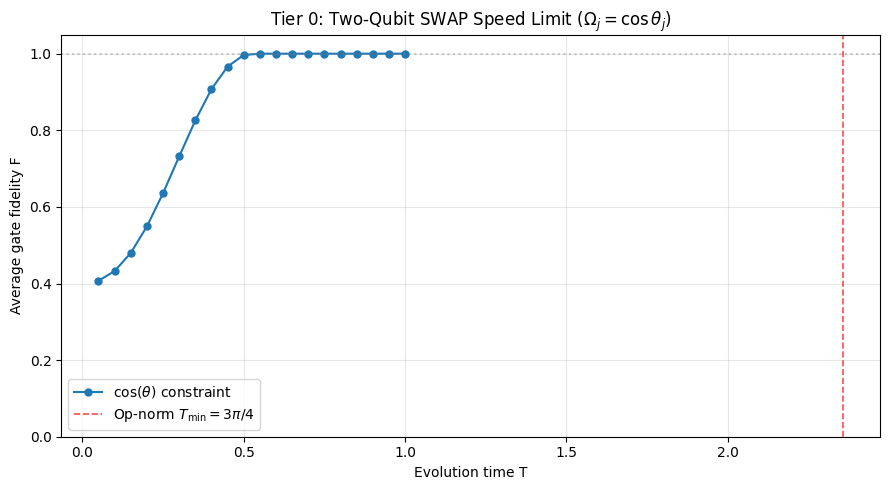


cos(theta) speed limit: F >= 0.999 first at T = 0.5500
Compare to op-norm speed limit: T_min = 2.3562
Speedup factor: 4.3x


In [10]:
# Tier 0 cos(theta) sweep: two-qubit SWAP with per-coefficient cosine bound
M_cos = 40
T_values_cos_t0 = np.linspace(0.05, 1.0, 20)

print("Tier 0 cos(theta) sweep: 15 Pauli generators, each |Omega_j| <= 1")
print(f"Max ||H_k||_op = 15 (if all coefficients saturate)")
print(f"Sweeping T in [{T_values_cos_t0[0]:.2f}, {T_values_cos_t0[-1]:.2f}], M = {M_cos}\n")

fid_cos_t0 = sweep_fidelity(
    generators_t0, U_swap, T_values_cos_t0, M=M_cos, label="T0-cos",
    n_restarts=30, epochs=4000, lr=0.005,
    constraint="cosine", init_scale=1.0, use_fast=False, verbose=False,
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_values_cos_t0, fid_cos_t0, 'o-', ms=5, label=r"$\cos(\theta)$ constraint")
ax.axvline(T_min_exact, color='r', ls='--', lw=1.2, alpha=0.7,
           label=f"Op-norm $T_{{\\min}} = 3\\pi/4$")
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.set(xlabel="Evolution time T", ylabel="Average gate fidelity F")
ax.set_title(r"Tier 0: Two-Qubit SWAP Speed Limit ($\Omega_j = \cos\theta_j$)")
ax.legend()
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find speed limit
above_99 = T_values_cos_t0[fid_cos_t0 >= 0.999]
if len(above_99) > 0:
    print(f"\ncos(theta) speed limit: F >= 0.999 first at T = {above_99[0]:.4f}")
    print(f"Compare to op-norm speed limit: T_min = {T_min_exact:.4f}")
    print(f"Speedup factor: {T_min_exact / above_99[0]:.1f}x")
else:
    print("\nF never reached 0.999 in sweep range — try larger T values")

### d=2 speed limit sweep with $\cos(\theta)$

All 27 generators for d=2 have $\|G_j\|_{\mathrm{op}} = 1$ (Pauli tensor products),
so the cosine and cosine-normalized constraints are identical.

In [13]:
# d=2 cos(theta) sweep
M_cos_d2 = 40
T_values_cos_d2 = np.linspace(0.5, 2, 5)

print(f"d=2 cos(theta) sweep: {len(labels_d2)} generators, M = {M_cos_d2}")
print(f"All generators have ||G_j||_op = 1.0")
print(f"Sweeping T in [{T_values_cos_d2[0]:.1f}, {T_values_cos_d2[-1]:.1f}]\n")

fid_cos_d2 = sweep_fidelity(
    generators_d2, U_target_d2, T_values_cos_d2, M=M_cos_d2, label="d2-cos",
    n_restarts=50, epochs=5000, lr=0.005,
    constraint="cosine", init_scale=1.0, use_fast=True, verbose=False,
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_values_cos_d2, fid_cos_d2, 'o-', ms=5, color="C0",
        label=r"d=2, $\cos(\theta)$")
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axhline(0.999, color='gray', ls='--', alpha=0.3, label="F = 0.999")
ax.set(xlabel="Evolution time T", ylabel="Average gate fidelity F")
ax.set_title(r"d=2: Qudit-Mediated SWAP Speed Limit ($\Omega_j = \cos\theta_j$)")
ax.legend()
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

above_999 = T_values_cos_d2[fid_cos_d2 >= 0.999]
if len(above_999) > 0:
    print(f"\nd=2 cos(theta) speed limit: F >= 0.999 first at T = {above_999[0]:.4f}")
else:
    print("\nd=2: F never reached 0.999 in sweep range")

d=2 cos(theta) sweep: 27 generators, M = 40
All generators have ||G_j||_op = 1.0
Sweeping T in [0.5, 8.0]

  [d2-cos] T = 0.500  |  F = 0.60201812  (1/20)
  [d2-cos] T = 0.895  |  F = 0.99860179  (2/20)
  [d2-cos] T = 1.289  |  F = 1.00000000  (3/20)
  [d2-cos] T = 1.684  |  F = 1.00000000  (4/20)
  [d2-cos] T = 2.079  |  F = 1.00000000  (5/20)


KeyboardInterrupt: 

### d=4 speed limit sweep with $\cos(\theta)$ and $\cos(\theta)/\|G_j\|_{\mathrm{op}}$

For d=4, the spin-3/2 operators have $\|S_x\|_{\mathrm{op}} = \|S_y\|_{\mathrm{op}} = \|S_z\|_{\mathrm{op}} = 3/2$,
so generators involving spin operators have larger norms. We run two variants:

1. **cosine**: $\Omega_j = \cos(\theta_j) \in [-1,1]$ — same bound for all generators
2. **cosine_normalized**: $\Omega_j = \cos(\theta_j)/\|G_j\|_{\mathrm{op}}$ — each term $\Omega_j G_j$ has $\|.\|_{\mathrm{op}} \le 1$

d=4 cos(theta) sweep: 27 generators, M = 40
Generator norms: some are 1.0 (Pauli-only), some are 1.5 (spin-3/2)
Sweeping T in [1.0, 12.0]

--- constraint = cosine ---
  [d4-cos] T = 1.000  |  F = 0.48388299  (1/20)
  [d4-cos] T = 1.579  |  F = 0.90103170  (2/20)
  [d4-cos] T = 2.158  |  F = 0.94738817  (3/20)
  [d4-cos] T = 2.737  |  F = 0.99997744  (4/20)
  [d4-cos] T = 3.316  |  F = 0.99999671  (5/20)
  [d4-cos] T = 3.895  |  F = 0.99999982  (6/20)
  [d4-cos] T = 4.474  |  F = 1.00000000  (7/20)
  [d4-cos] T = 5.053  |  F = 1.00000000  (8/20)
  [d4-cos] T = 5.632  |  F = 1.00000000  (9/20)
  [d4-cos] T = 6.211  |  F = 1.00000000  (10/20)
  [d4-cos] T = 6.789  |  F = 1.00000000  (11/20)
  [d4-cos] T = 7.368  |  F = 1.00000000  (12/20)
  [d4-cos] T = 7.947  |  F = 1.00000000  (13/20)
  [d4-cos] T = 8.526  |  F = 1.00000000  (14/20)
  [d4-cos] T = 9.105  |  F = 1.00000000  (15/20)
  [d4-cos] T = 9.684  |  F = 1.00000000  (16/20)
  [d4-cos] T = 10.263  |  F = 1.00000000  (17/20)
  [d4-co

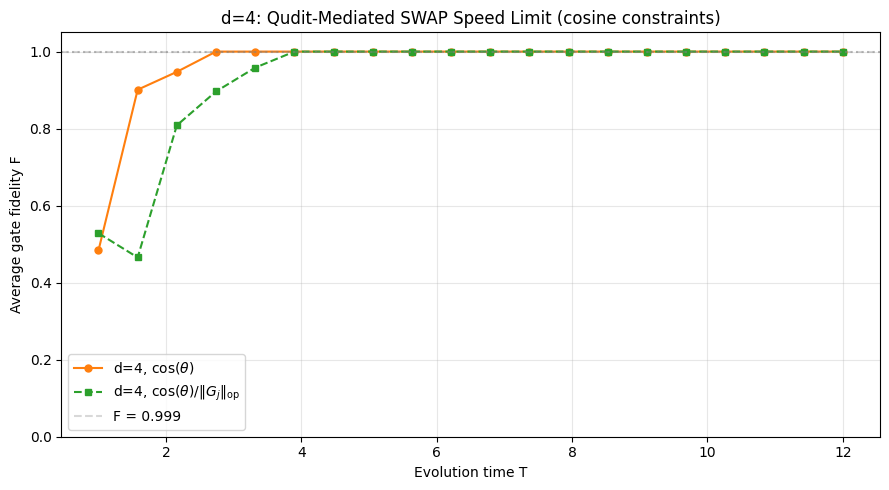

  d=4 cos: F >= 0.999 first at T = 2.7368
  d=4 cos_norm: F >= 0.999 first at T = 3.8947


In [14]:
# d=4 cos(theta) sweep
M_cos_d4 = 40
T_values_cos_d4 = np.linspace(1.0, 12.0, 20)

print(f"d=4 cos(theta) sweep: {len(labels_d4)} generators, M = {M_cos_d4}")
print(f"Generator norms: some are 1.0 (Pauli-only), some are 1.5 (spin-3/2)")
print(f"Sweeping T in [{T_values_cos_d4[0]:.1f}, {T_values_cos_d4[-1]:.1f}]\n")

# Run cosine constraint
print("--- constraint = cosine ---")
fid_cos_d4 = sweep_fidelity(
    generators_d4, U_target_d4, T_values_cos_d4, M=M_cos_d4, label="d4-cos",
    n_restarts=50, epochs=5000, lr=0.005,
    constraint="cosine", init_scale=1.0, use_fast=True, verbose=False,
)

# Run cosine_normalized constraint
print("\n--- constraint = cosine_normalized ---")
fid_cosnorm_d4 = sweep_fidelity(
    generators_d4, U_target_d4, T_values_cos_d4, M=M_cos_d4, label="d4-cosnorm",
    n_restarts=50, epochs=5000, lr=0.005,
    constraint="cosine_normalized", init_scale=1.0, use_fast=True, verbose=False,
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_values_cos_d4, fid_cos_d4, 'o-', ms=5, color="C1",
        label=r"d=4, $\cos(\theta)$")
ax.plot(T_values_cos_d4, fid_cosnorm_d4, 's--', ms=5, color="C2",
        label=r"d=4, $\cos(\theta)/\|G_j\|_{\mathrm{op}}$")
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axhline(0.999, color='gray', ls='--', alpha=0.3, label="F = 0.999")
ax.set(xlabel="Evolution time T", ylabel="Average gate fidelity F")
ax.set_title(r"d=4: Qudit-Mediated SWAP Speed Limit (cosine constraints)")
ax.legend()
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for label, fids in [("cos", fid_cos_d4), ("cos_norm", fid_cosnorm_d4)]:
    above_999 = T_values_cos_d4[fids >= 0.999]
    if len(above_999) > 0:
        print(f"  d=4 {label}: F >= 0.999 first at T = {above_999[0]:.4f}")
    else:
        print(f"  d=4 {label}: F never reached 0.999 in sweep range")